# Analysis of a 2D Cylindrical Potential Well in Quantum Mechanics
Mehmet Janjua - S6062431

The quantum mechanical behaviour of a particle confined in a two-dimensional cylindrical (finite) potential well, with a non-uniform (quadratic) shape. The fundamental goal is to solve the Time-Independent Schrödinger equation for this system to determine the eigenvalues (energy levels) and eigenfunctions (states) for diff

The project is split into three sections:
1. Computing the allowed energy eigenvalues and identifying the lowest ones.
2. Constructing and modeling the radial wavefunction to observe how the eigenvalues in ϕ affect radial wavefunctions and energy values.
3. Determining if the system has degenerate energy levels.

### Theory

The potential of the system is a quadratic well of radius $R_0=1$ with a finite barrier of height $V_0=50$:

$$
V(r) = 
\begin{cases} 
V_0 r^2 & \text{for } r < R_0 \\
V_0 & \text{for } r \ge R_0 
\end{cases}
$$

The TISE in two-dimensions is:

$$-\frac{\hbar^2}{2m} \nabla^2 \Psi(x, y) + V(x, y) \Psi(x, y) = E \Psi(x, y)$$

Given the cylindrical symmetry of system, where $V(x, y) = V(r)$, it is most convenient to switch to polar coordinates $(r, \phi)$. Using natural units where $m/\hbar^2 = 1$, the TISE becomes:

$$-\frac{1}{2} \left( \frac{\partial^2}{\partial r^2} + \frac{1}{r}\frac{\partial}{\partial r} + \frac{1}{r^2}\frac{\partial^2}{\partial \phi^2} \right) \Psi(r, \phi) + V(r) \Psi(r, \phi) = E \Psi(r, \phi)$$

This is solved using separation of variables by taking:

$$ \Psi(r, \phi) = R(r)\Phi(\phi) $$

Substituting into the TISE and solving gives us two parts: one that depends only on the radius $r$, and another that depends only on the angle $ϕ$. For the equation to hold for all values of $r$ and $ϕ$, both parts must be equal to a constant. Setting this constant to $l^2$

We obtain two different ODEs:

1.  **The Angular Equation:**
    $$
    \frac{d^2\Phi(\phi)}{d\phi^2} = -l^2\Phi(\phi)
    $$
    The solution to this is $\Phi(\phi) = e^{il\phi}$. For the wavefunction to be single-valued (i.e., the same after a full circle), $l$ must be an integer ($l = 0, \pm1, \pm2, \dots$), known as the angular momentum quantum number.

2.  **The Radial Equation:**
    $$
    -\frac{1}{2}\left(\frac{d^2R(r)}{dr^2} + \frac{1}{r}\frac{dR(r)}{dr}\right) + \left(V(r) + \frac{l^2}{2r^2}\right)R(r) = ER(r)
    $$
    This is the final equation that is solved numerically to find the energy eigenvalues $E$ and the radial wavefunctions $R(r)$ for each value of $l$.

### The Matrix Method

The matrix method is employed to solv the TISE numerically. The unkown radial function
To solve the TISE numerically, we use the matrix method. The core idea is to approximate the unknown radial wavefunction, $R(r)$, as a linear combination of a finite set of known basis functions, $\phi_n(r)$. We place the system in an artificial infinite well of width $B$, allowing us to use its sine eigenfunctions as our basis:

$$R(r) \approx \sum_{n=1}^{N} c_n \phi_n(r) \quad \text{where} \quad \phi_n(r) = \sqrt{\frac{2}{B}} \sin\left(\frac{n\pi r}{B}\right)$$

Substituting this expansion into the radial part of the TISE transforms the differential equation into a matrix eigenvalue equation:

$$ \mathbf{H} \vec{c} = E \vec{c} $$

Where, $\mathbf{H}$ is the Hamiltonian matrix, whose elements $H_{mn}$ are calculated by the integral:

$$ H_{mn} = \int_0^{B} \phi_m(r) \left[-\frac{1}{2}\left(\frac{d^2}{dr^2} + \frac{1}{r}\frac{d}{dr}\right) + V(r) + \frac{l^2}{2r^2}\right] \phi_n(r) \, r \, dr $$

Where $V_{eff}$ can be defined as: 

$$ V_{eff} = V(r) + \frac{l^2}{2r^2} $$
Solving this matrix problem yields $N$ eigenvalues (the energy levels $E$) and their corresponding eigenvectors (the coefficients $\vec{c}$).


ENERGY LEVELS (EIGENVALUES)
             l=0        l=1        l=2        l=3
State                                            
n=1     3.928176   6.274384  12.419025  20.046660
n=2    15.572510  17.171202  22.557638  32.481414
n=3    35.925327  36.918413  40.108920  46.654648
n=4    62.551206  63.161993  65.030246  68.337175

LOWEST ENERGY LEVELS:
        E₀
l=0   3.93
l=1   6.27
l=2  12.42
l=3  20.05

EIGENFUNCTIONS FOR l = 0
                     State 0   State 1   State 2   State 3   State 4  \
Basis Function (n)                                                     
1                  -0.088907 -0.127004 -0.168949  0.278630 -0.330863   
2                  -0.171043 -0.231622 -0.282243  0.394025 -0.346960   
3                  -0.240622 -0.296260 -0.304572  0.288736 -0.046581   
4                  -0.293585 -0.311625 -0.232285  0.038595  0.282088   
5                  -0.328026 -0.277840 -0.092101 -0.209738  0.359928   

                     State 5   State 6   State 7   State 8   S

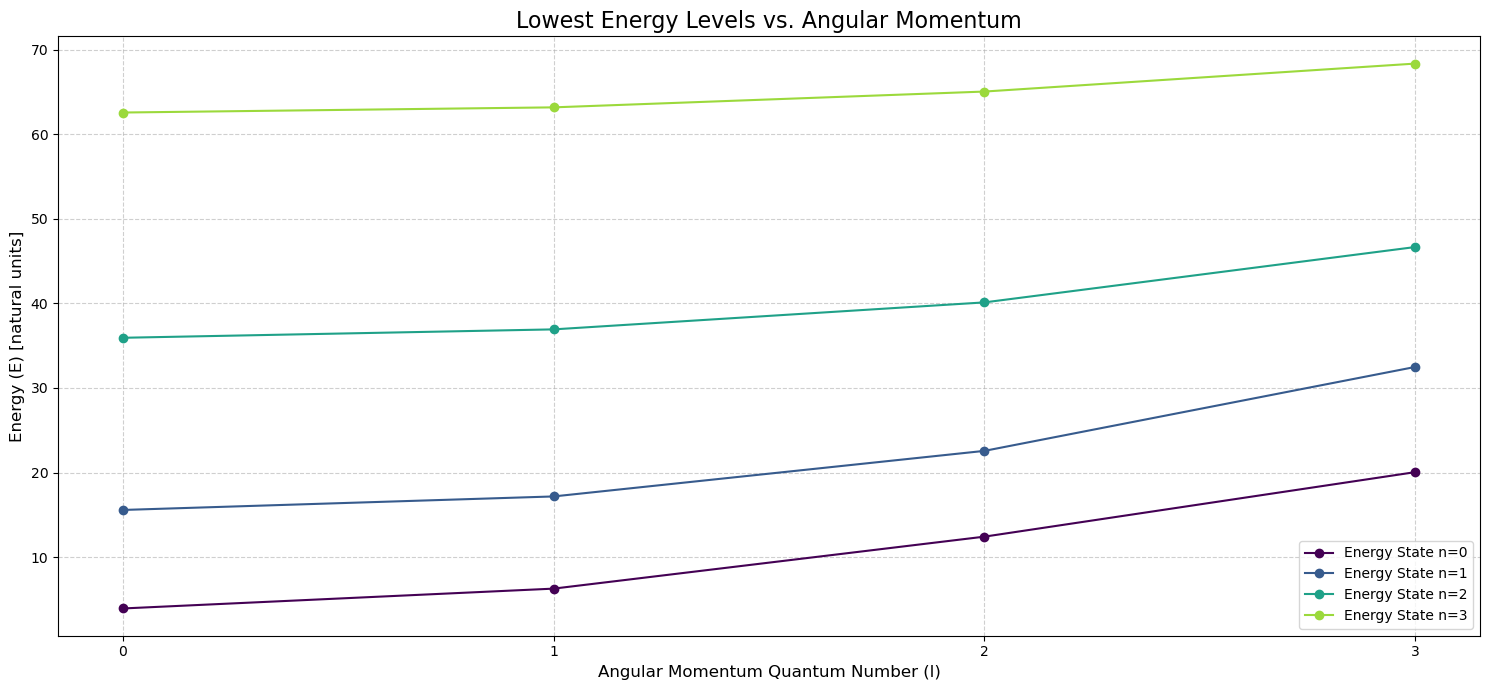

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad, simpson
from scipy.linalg import eigh

V0 = 50 # Potential barrier height
R0 = 1 # Radius of well (in natural units)
N = 20 # Basis size (high for better accuracy)
B = 5 # Hypothetical width of infinite well basis
number_of_states = 4 # Number of energy states to compute and plot
angular_momentum_count = number_of_states 
angular_momentum = [l for l in range(number_of_states)]  # List of angular momentum values to compute

def potential(r):
    """
    Returns the potential V(r) as defined for the system
    """
    return V0 * r**2 if r<R0 else V0


def phi(n, r):
    """
    Returns the n-th basis function
    """
    return np.sqrt(2/B) * np.sin(n*np.pi*r/B)


def dphi(n, r):
    """
    Returns the first derivative of the n-th basis function
    """
    return np.sqrt(2/B) * (n * np.pi / B) * np.cos(n * np.pi * r / B)


def ddphi(n, r):
    """
    Returns the second derivative of the n-th basis function
    """
    return - (n*np.pi/B)**2 * phi(n, r)


def compute_hamiltonian(l_list):
    """
    Computes the Hamiltonian matrix for each angular momentum value in l_list
    and returns a dictionary with eigenvalues and eigenvectors for each l
    """

    results = {} # Intialize results dictionary

    # Loop over each angular momentum value
    for l in l_list:
        H = np.zeros((N, N)) # Hamiltonian matrix

        # Compute matrix elements H[m, n]
        for n in range(1, N+1):
            for m in range(1, N+1):
                # Kinetic energy term: -1/2 * (d^2/dr^2 + 1/r * d/dr)
                kinetic_integrand = lambda r: phi(m,r) * (-0.5) * (ddphi(n, r) + (1/r)*dphi(n,r)) * r

                # Potential energy term: V(r) + l^2/(2r^2)
                potential_integrand = lambda r: phi(m,r) * (potential(r) + l**2 / (2*r**2)) * phi(n,r) * r
                
                # Integrate to get matrix elements (start from 1e-6 to avoid 1/r singularity)
                kinetic_energy, _ = quad(kinetic_integrand, 1e-6, B, limit=100)
                potential_energy, _ = quad(potential_integrand, 1e-6, B, limit=100)
                
                H[m-1, n-1] = kinetic_energy + potential_energy # Assign values

        # Solve the eigenvalue problem and store results
        eigenvalues, eigenvectors = eigh(H)
        results[l] = {'energies': eigenvalues, 'vectors': eigenvectors}

    return results

hamiltonian = compute_hamiltonian(angular_momentum)

energy_data = {}
state_data = {}

# Extract energies and states for each angular momentum
for l in angular_momentum:
    energy_data[l] = hamiltonian[l]['energies'][:number_of_states]
    state_data[l] = hamiltonian[l]['vectors'][:]

# Convert to DataFrame and display
df_energies = pd.DataFrame(energy_data)
df_energies.index.name = "State" # Name the index
df_energies.columns = [f'l={l}' for l in angular_momentum] # Rename columns to indicate l values
df_energies.rename(index=lambda x: f"n={x+1}", inplace=True) # Make index 1-based for display
print('\nENERGY LEVELS (EIGENVALUES)')
print(df_energies)

# Display lowest energy levels for each angular momentum
lowest_energies = {l: round(energy_data[l][0], 2) for l in angular_momentum} # Lowest energy for each l
df_lowest_energies = pd.DataFrame.from_dict(lowest_energies, orient='index', columns=['Lowest Energy (natural units)'])
df_lowest_energies.rename(index=lambda x: f"l={x}", inplace=True) 
df_lowest_energies.columns = ['E₀'] # Rename column to E₀
print("\nLOWEST ENERGY LEVELS:")
print(df_lowest_energies)

# Display eigenfunctions for each value of l
column_names = [f'State {n}' for n in range(N)]
for i in range(number_of_states):
    eigenfunctions = state_data[i]
    df_eigenfunctions = pd.DataFrame(eigenfunctions, columns=column_names)
    df_eigenfunctions.index.name = 'Basis Function (n)'
    df_eigenfunctions.index += 1 # To make it 1-based
    print(f'\nEIGENFUNCTIONS FOR l = {i}')
    print(df_eigenfunctions.head(5)) # Display first 5 basis functions

# Plotting the Energy Level Diagram
plt.figure(figsize=(15, 7))

# Define a color map for different states
colors = plt.cm.viridis(np.linspace(0, 0.85, number_of_states))

# Plot each energy state for values of l
for state_index in range(number_of_states):
    # Extract energies for this state for all l
    energies_for_state = [hamiltonian[l]['energies'][state_index] for l in angular_momentum]
    plt.plot(angular_momentum, energies_for_state, 'o-', label=f'Energy State n={state_index}', color=colors[state_index])

# Add titles and labels
plt.title('Lowest Energy Levels vs. Angular Momentum', fontsize=16)
plt.xlabel('Angular Momentum Quantum Number (l)', fontsize=12)
plt.ylabel('Energy (E) [natural units]', fontsize=12)

# Customize x-ticks based on number of points (if number_of_states is too high, axes get cluttered)
num_points = len(angular_momentum)

if num_points <= 20:
    step = 1
elif num_points <= 50:
    step = 5
else:
    step = 10

plt.xticks(angular_momentum[::step])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

The tables above summarize the calculated energy eigenvalues for each state, defined by the quantum numbers (n,l). The first table provides a comprehensive overview, while the second highlights the ground state energy ($E₀$​) for each value of l. Subsequently, the eigenstates for each value of $l$ is displayed.

The energy dependence is visualized in the plot above, which shows the energy eigenvalues for the four lowest quantum states $(n=0, 1, 2, 3)$ as a function fo the angular momentum quantum number $l$.

The plot clearly confirms the expected physical behavior; for a state n, the energy $E$ increases as $l$ increases. This effect is due to the term $\frac{l^2}{2r^2}$ in the radial TISE. This term acts as an additional repulsive potential that raises the total energy of the system for states with non-zero angular momentum.

Note: All energies are in natural units.


Energy Increase Due to Angular Momentum (E = E(n, l) - E(n,0)):
       ΔE(l=1)  ΔE(l=2)  ΔE(l=3)
State                           
n=1      2.346    8.491   16.118
n=2      1.599    6.985   16.909
n=3      0.993    4.184   10.729
n=4      0.611    2.479    5.786


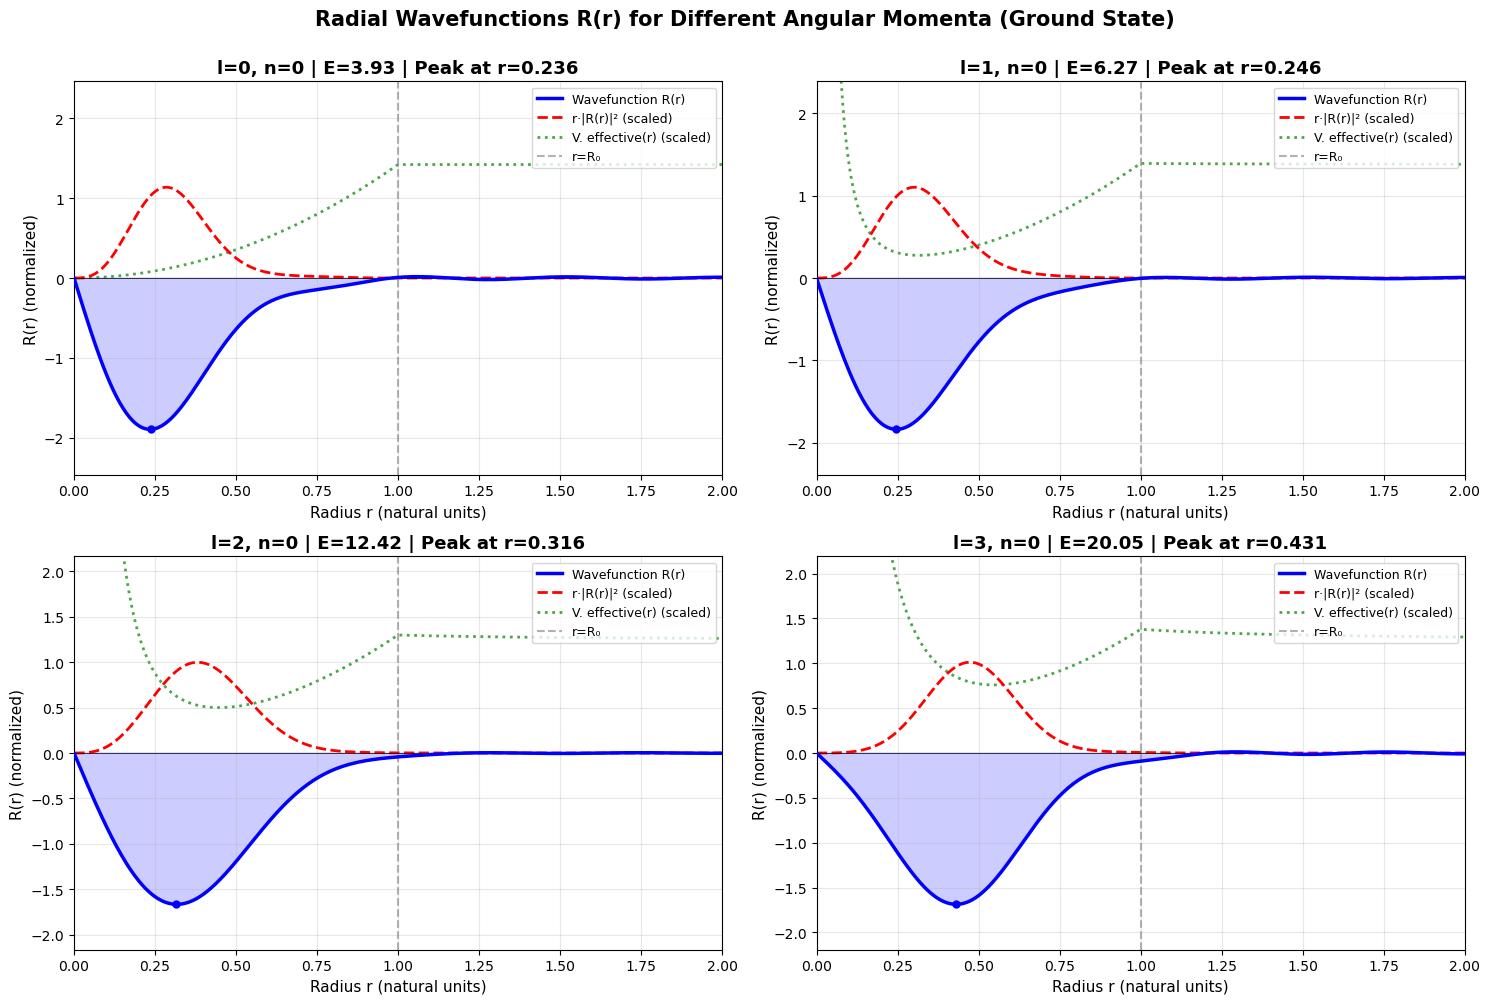

In [68]:
# Calculate and display energy increase due to different values of l
print("\nEnergy Increase Due to Angular Momentum (E = E(n, l) - E(n,0)):")
# Subtract the l=0 energies from all other energies to get the increase
df_deltaE = df_energies.subtract(df_energies['l=0'], axis=0) 
df_deltaE = df_deltaE.drop(columns='l=0')
df_deltaE.columns = [f"ΔE({col})" for col in df_deltaE.columns]
print(df_deltaE.to_string(float_format=lambda x: f'{x:.3f}')) 

# Initialize plotting parameters
r_values = np.linspace(0.001, B, 1000)
l_values_to_plot = [0, 1, 2, 3] 
n_state = 0 # Ground state (can be changed to plot other states)

# Create subplots for each l value to plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() 

# 
for idx, l in enumerate(l_values_to_plot):
    ax = axes[idx] # Select subplot
    eigenvec = hamiltonian[l]['vectors'][:, n_state]
    
    # Reconstruct wavefunction
    psi_r = np.zeros_like(r_values)
    for i, r in enumerate(r_values):
        for n in range(1, N+1):
            psi_r[i] += eigenvec[n-1] * phi(n, r)
    
    # Normalize
    norm = simpson(psi_r**2 * r_values, x=r_values)
    
    # Plot wavefunction
    ax.plot(r_values, psi_r, 'b-', linewidth=2.5, label='Wavefunction R(r)', zorder=3)
    ax.fill_between(r_values, 0, psi_r, alpha=0.2, color='blue')
    
    # Plot radial probability density (scaled)
    radial_prob = r_values * psi_r**2
    if np.max(radial_prob) > 0:
        scale = 0.6 * np.max(np.abs(psi_r)) / np.max(radial_prob)
        ax.plot(r_values, radial_prob * scale, 'r--', linewidth=2, label='r·|R(r)|² (scaled)', zorder=2)
    
    # Plot effective potential (scaled)
    V_eff = np.array([potential(r) + l**2/(2*r**2) if r > 0 else 100 for r in r_values])
    V_eff = np.minimum(V_eff, 100)
    if np.max(np.abs(psi_r)) > 0:
        V_scale = 0.015 * np.max(np.abs(psi_r))
        ax.plot(r_values, V_eff * V_scale, 'g:', linewidth=2, alpha=0.7, label='V. effective(r) (scaled)', zorder=1)
    
    # Details and aesthetics of the plot
    ax.axvline(R0, color='gray', linestyle='--', alpha=0.6, linewidth=1.5, label='r=R₀')
    ax.axhline(0, color='k', linewidth=0.5)
    peak_idx = np.argmax(np.abs(psi_r))
    peak_pos = r_values[peak_idx]
    ax.plot(peak_pos, psi_r[peak_idx], 'bo', markersize=5, zorder=4)
    
    # Title and labels
    E_val = hamiltonian[l]['energies'][n_state] # Energy value for title
    ax.set_title(f'l={l}, n={n_state} | E={E_val:.2f} | Peak at r={peak_pos:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Radius r (natural units)', fontsize=11)
    ax.set_ylabel('R(r) (normalized)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 2)
    y_max = max(np.abs(psi_r)) * 1.3
    ax.set_ylim(-y_max, y_max)

plt.suptitle('Radial Wavefunctions R(r) for Different Angular Momenta (Ground State)', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

The "Energy Increase" table above quantifies the energy difference $\Delta E = E(n, l) - E(n, 0)$ for different values of $l$. This makes it clear that adding angular momentum to a state increases the energy of the system. Therefore, eiegenvalues of $ϕ$ do affect radial wavefunctions and energy values.

The plots above, visualising the ground state wavefunctions $(n=0)$ for the first 4 values of $l$, subtly demonstrate this effect.
Each subplot displays the wavefunction $R(r)$, the radial probability density $r|R(r)|^2$, and a scaled effective potential $V_{eff}(r)$.

* For the **$l=0$ state**, the particle is most likely to be found close to the origin radius, as shown by the peak of the **radial probability density** $r|R(r)|^2$ (the red dashed line). The peak of the wavefunction amplitude $R(r)$ is also slightly offset from $r=0$, which is due to the numerical matrix method, where we take $\phi_n(r)$ to be a function of sine, which is zero at the origin – this results in all basis functions ($\phi_n(r)$) to be zero at the origin.

* For states with **$l > 0$**, the wavefunction is visibly pushed away from the origin. As $l$ increases, the peak of both the wavefunction and the probability density shifts to a progressively larger radius.

The repulsive $\frac{l^2}{2r^2}$ term in the effective potential makes it energetically restricting for a particle with angular momentum to occupy the region near $r=0$.

DEGENERACY TABLE
------------------------------------------------------------
n     l values     Energy       Degeneracy  
------------------------------------------------------------
0     0            3.928        1 (non-deg) 
0     ±1           6.274        2 (degenerate)
0     ±2           12.419       2 (degenerate)
0     ±3           20.047       2 (degenerate)

1     0            15.573       1 (non-deg) 
1     ±1           17.171       2 (degenerate)
1     ±2           22.558       2 (degenerate)
1     ±3           32.481       2 (degenerate)

2     0            35.925       1 (non-deg) 
2     ±1           36.918       2 (degenerate)
2     ±2           40.109       2 (degenerate)
2     ±3           46.655       2 (degenerate)

3     0            62.551       1 (non-deg) 
3     ±1           63.162       2 (degenerate)
3     ±2           65.030       2 (degenerate)
3     ±3           68.337       2 (degenerate)



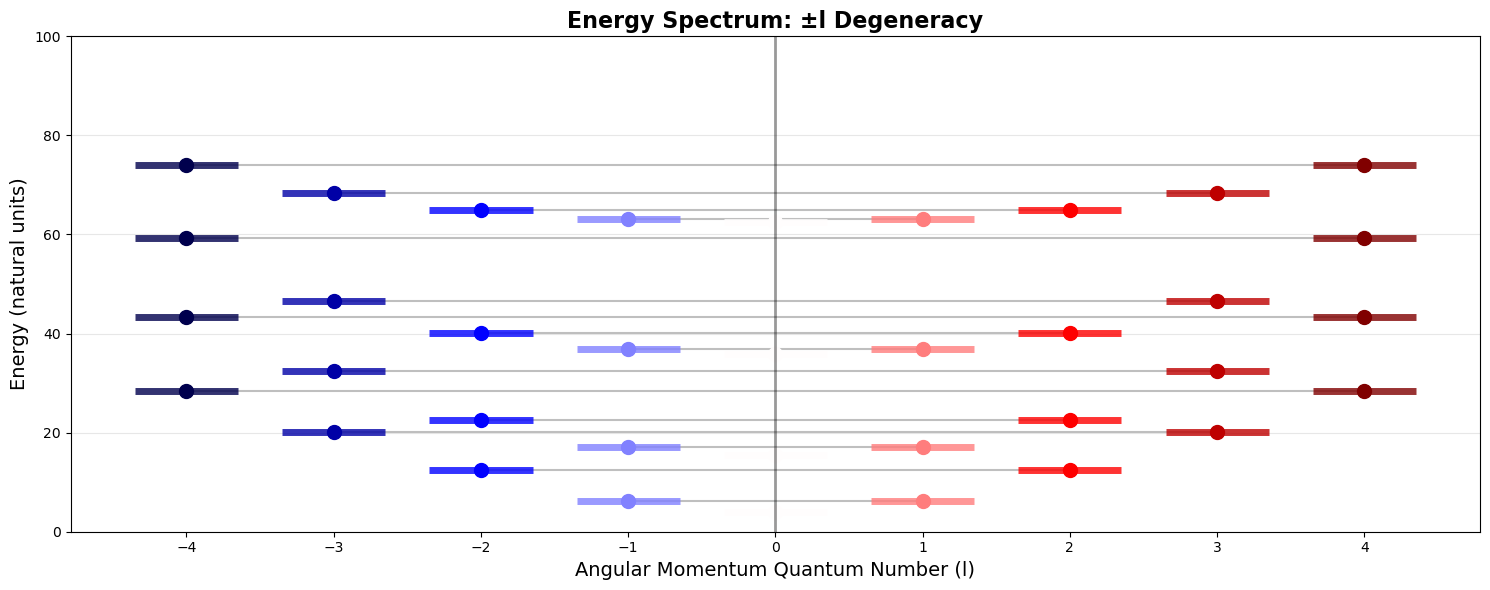

In [69]:
l_max = 4 # Max number of l to display
n_levels_to_show = l_max # Number of energy levels to show
l_list = [i for i in range(-l_max, l_max + 1)]

# Recompute Hamiltonian for full l range
degeneracy_h = compute_hamiltonian(l_list)

# Create the degeneracy table
print("DEGENERACY TABLE")
print("-"*60)
print(f"{'n':<5} {'l values':<12} {'Energy':<12} {'Degeneracy':<12}")
print("-"*60)

# Loop over principal quantum number n and angular momentum l to display energies and degeneracies
for n in range(l_max):
    # l=0 case (non-degenerate)
    E0 = degeneracy_h[0]['energies'][n] # Energy for l=0
    print(f"{n:<5} {'0':<12} {E0:<12.3f} {'1 (non-deg)':<12}")
    
    # non l=0 cases (degenerate pairs)
    for l_abs in range(1, min(4, l_max+1)):
        E = degeneracy_h[l_abs]['energies'][n] # Energy for ±l
        l_vals = f'±{l_abs}'
        print(f"{n:<5} {l_vals:<12} {E:<12.3f} {'2 (degenerate)':<12}")
    print()

# Plotting the Degeneracy Diagram
plt.figure(figsize=(15, 6))
colors = plt.cm.seismic(np.linspace(0, 1, len(l_list))) # Color map

# Energy spectrum plot for ±l values of energy
for idx, l in enumerate(l_list):
    E_list = degeneracy_h[l]['energies'][:n_levels_to_show]
    plt.hlines(E_list, l-0.35, l+0.35, linewidth=5, color=colors[idx], alpha=0.8)
    plt.plot([l]*len(E_list), E_list, 'o', markersize=10, color=colors[idx])

# Draw horizontal lines connecting ±l degenerate levels
for n in range(n_levels_to_show):
    for l_pos in range(1, l_max + 1):
        if l_pos in degeneracy_h and -l_pos in degeneracy_h:
            E = degeneracy_h[l_pos]['energies'][n] # Energy for ±l
            plt.plot([l_pos, -l_pos], [E, E], 'gray', linewidth=1.5, alpha=0.5, zorder=0)

# Add titles and labels
plt.axvline(0, color='k', linestyle='-', linewidth=2, alpha=0.4)
plt.xlabel('Angular Momentum Quantum Number (l)', fontsize=14)
plt.ylabel('Energy (natural units)', fontsize=14)
plt.title('Energy Spectrum: ±l Degeneracy', fontsize=16, fontweight='bold')
plt.xticks(l_list)
plt.ylim(0, 100) # display up to 100 natural units (energy range)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The table and plot above clearly show that the system has degenerate levels for all states with non-zero angular momentum ($l > 0$).

* The "DEGENERACY TABLE" explicitly groups the $±l$ states and lists a single, shared energy value for each pair. This means that the states with opposite angular momentum have identical energy, while the $l=0$ state is correctly identified as non-degenerate.

* The plot visually shows the degeneracy of present for different values of $l$. For each energy state $n$, a horizontal gray line connects the energy levels for each $+l$ and $-l$ pair. The fact that these lines are perfectly horizontal demonstrates that the energy levels are identical.

This degeneracy is a result of the system's cylindrical symmetry. The radial TISE depends only on **$l^2$**, meaning the energy of a state is independent of the sign of its angular momentum. Therefore, the states for $+l$ and $-l$ are physically distinct but have the same energy.

The AI model Gemini 2.5 was used to as a tool for conceptual clarification of the physical system, for debugging the code, and for generating the LaTeX for the mathematical equations in the Markdown cells.